--- Best Fit Line Metrics ---
Linear Reg MSE: 4.68,R2: 0.90
SVM Reg MSE: 4.52,R2: 0.91


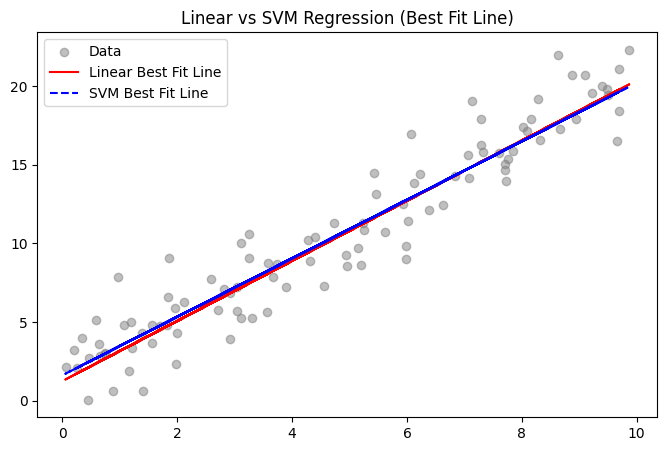


Fetching Boston Housing data from OpenML...
      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-nu

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

np.random.seed(42)
X_line = 10* np.random.rand(100, 1)
y_line = 2 * X_line.ravel() + 1 + np.random.randn(100) * 2

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_line, y_line, test_size=0.2)

lin_reg = LinearRegression().fit(X_train_l, y_train_l)
svr_lin = SVR(kernel='linear', C=1.0).fit(X_train_l, y_train_l)
y_pred_lin=lin_reg.predict(X_test_l)
y_pred_svr=svr_lin.predict(X_test_l)
print("--- Best Fit Line Metrics ---")
print(f"Linear Reg MSE: {mean_squared_error(y_test_l, y_pred_lin):.2f},R2: {r2_score(y_test_l, y_pred_lin):.2f}")
print(f"SVM Reg MSE: {mean_squared_error(y_test_l,y_pred_svr):.2f},R2: {r2_score(y_test_l, y_pred_svr):.2f}")
plt.figure(figsize=(8, 5))
plt.scatter(X_line, y_line, color='grey',alpha=0.5, label='Data')
plt.plot(X_line, lin_reg.predict(X_line), color='red', label='Linear Best Fit Line')
plt.plot(X_line, svr_lin.predict(X_line), color='blue', linestyle='--' , label='SVM Best Fit Line')
plt.legend()
plt.title("Linear vs SVM Regression (Best Fit Line)")
plt.show()

# --- Boston Housing Dataset Regression ---
print("\nFetching Boston Housing data from OpenML...")
boston = fetch_openml(name='boston', version=1, as_frame=True, parser='auto')
X = boston.data.copy() # Added .copy() to prevent SettingWithCopyWarning
y = boston.target.astype(float)
df = X.copy()
df['MEDV'] = y

print(df.head())
print(df.info())

In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

print("\nFetching California Housing data...")
california_housing = fetch_california_housing(as_frame=True)

X_california = california_housing.data
y_california = california_housing.target

df_california = X_california.copy()
df_california['MedHouseVal'] = y_california

display(df_california.head())
print(df_california.info())


Fetching California Housing data...


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [3]:
X_train_cal, X_test_cal, y_train_cal, y_test_cal = train_test_split(
    X_california, y_california, test_size=0.2, random_state=42
)

In [4]:
lin_reg_cal = LinearRegression()
lin_reg_cal.fit(X_train_cal, y_train_cal)

svr_cal = SVR()
svr_cal.fit(X_train_cal, y_train_cal)

SVR()

In [5]:
y_pred_lin_cal = lin_reg_cal.predict(X_test_cal)
y_pred_svr_cal = svr_cal.predict(X_test_cal)

In [6]:
print("--- California Housing Linear Regression Performance ---")
print("MSE:", mean_squared_error(y_test_cal, y_pred_lin_cal))
print("R2 Score:", r2_score(y_test_cal, y_pred_lin_cal))

print("\n--- California Housing SVR Performance ---")
print("MSE:", mean_squared_error(y_test_cal, y_pred_svr_cal))
print("R2 Score:", r2_score(y_test_cal, y_pred_svr_cal))

--- California Housing Linear Regression Performance ---
MSE: 0.5558915986952444
R2 Score: 0.5757877060324508

--- California Housing SVR Performance ---
MSE: 1.3320115421348744
R2 Score: -0.01648536010717372


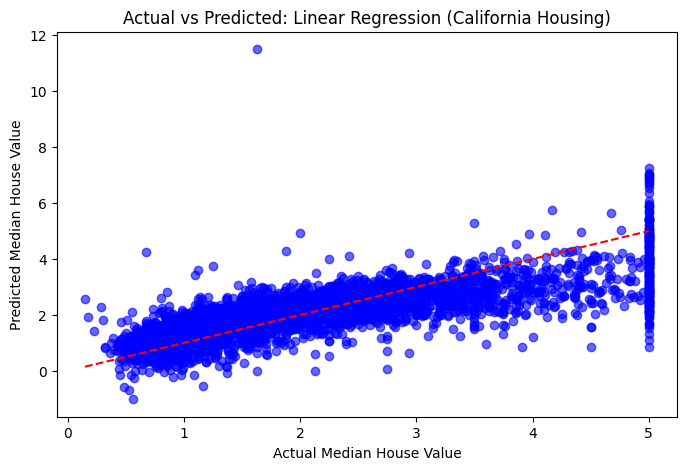

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test_cal, y_pred_lin_cal, c='blue', alpha=0.6)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted: Linear Regression (California Housing)")
plt.plot([y_test_cal.min(), y_test_cal.max()], [y_test_cal.min(), y_test_cal.max()], 'r--') # Identity line
plt.show()

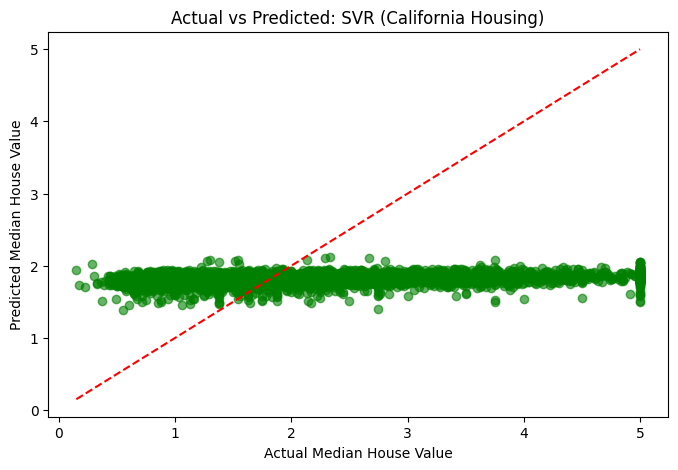

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test_cal, y_pred_svr_cal, c='green', alpha=0.6)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted: SVR (California Housing)")
plt.plot([y_test_cal.min(), y_test_cal.max()], [y_test_cal.min(), y_test_cal.max()], 'r--') # Identity line
plt.show()